In [1]:
from utilities import DataSimulator, prepare_data,plot_learning_curve, analyze_error_distribution, ks_test_gan_cdf,plot_bin_dist 
from my_cGAN import MyCGAN
import pandas as pd
import numpy as np


# DATA MANAGEMENT

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 3        # Number of time steps
J = 2        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

sim.get_paths()
sim.get_pdf(n_steps_ahead=10, n_bins=3)
sim.save_binary_file('data/inputs/demo')
print(sim.paths)
print(sim.pdf)

In [ ]:
file_paths, file_pdf = sim.load_binary_file('data/inputs/demo.bin')

In [ ]:
print(file_paths)
print(file_pdf)

# MEAN AND VARIANCE

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10)

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch= 100, name = 'CGAN_mean_std')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'mean_std_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/mean_std_error_dist.csv')
print(means,'\n', std, '\n', summary)

# BINS DISTRIBUTION PROBABILITIES 1


In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, verbose=True)
pdfs

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_p_error_dist.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_p_error_dist.csv')
print(means,'\n', std, '\n', summary)

In [ ]:
summary

## ks test 

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100        # Number of paths to simulate
SEED=1

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100)
bins = val.bins

In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_p')
conditional_gan.load_models()

In [4]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)


In [ ]:
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df

In [ ]:
generated_sample = generated[0]
true_sample = pdfs[0]

plot_bin_dist(true_sample, generated_sample, bins)



# BINS DISTRIBUTION PROBABILITIES 2


In [4]:
# data simulation 
# example
X0_range = (-1.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 0.5)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100)
sim.save_configuration('./models/bins/CGAN_bins_pglobal.json')
pdfs

Bins saved to models\bins\CGAN_bins_pglobal.json


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 100))

In [5]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='log')


conditional_gan = MyCGAN(max_epoch=200, name='CGAN_bins_pglobal')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1], is_prob = True)
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_pglobal_error_dist.csv')


Epoch: 0/200, Step: 0, D Loss: 1.3545688390731812, G Loss: 0.43937498331069946
Epoch: 0/200, Step: 500, D Loss: 0.6654068231582642, G Loss: 1.2256900072097778
Epoch: 0/200, Step: 1000, D Loss: 0.8134369254112244, G Loss: 0.9816923141479492
Epoch: 0/200, Step: 1500, D Loss: 1.0449250936508179, G Loss: 2.4504244327545166


c:\Users\matte\LEARNING\MAGISTRALE\QUANTITATIVE FINANCE\TESI\cGAN_code\my_cGAN.py:422: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  D_loss_list.append(round(float(D_loss), 4))


Epoch: 0/200, Step: 2000, D Loss: 1.1189521551132202, G Loss: 1.2810102701187134
Epoch: 0/200, Step: 2500, D Loss: 1.0908180475234985, G Loss: 0.7640148997306824
Epoch: 0/200, Step: 3000, D Loss: 1.1479909420013428, G Loss: 0.7963275909423828
Epoch: 1/200, Step: 3500, D Loss: 1.0486148595809937, G Loss: 1.2309075593948364
Epoch: 1/200, Step: 4000, D Loss: 0.8280725479125977, G Loss: 0.9900369644165039
Epoch: 1/200, Step: 4500, D Loss: 0.7770075798034668, G Loss: 1.9754836559295654
Epoch: 1/200, Step: 5000, D Loss: 1.0993168354034424, G Loss: 1.188766360282898
Epoch: 1/200, Step: 5500, D Loss: 0.9411842823028564, G Loss: 1.0365447998046875
Epoch: 1/200, Step: 6000, D Loss: 0.8389785289764404, G Loss: 1.4013561010360718
Epoch: 2/200, Step: 6500, D Loss: 1.115111231803894, G Loss: 0.8989302515983582
Epoch: 2/200, Step: 7000, D Loss: 1.2388279438018799, G Loss: 1.5502128601074219
Epoch: 2/200, Step: 7500, D Loss: 1.0715665817260742, G Loss: 1.3862076997756958
Epoch: 2/200, Step: 8000, D Lo

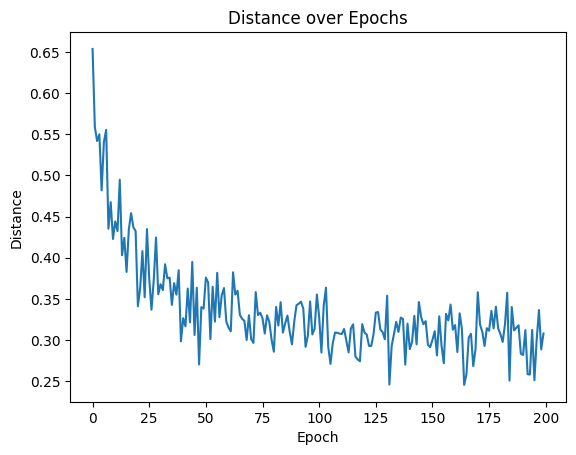

In [6]:
plot_learning_curve('generated_vs_true.csv')

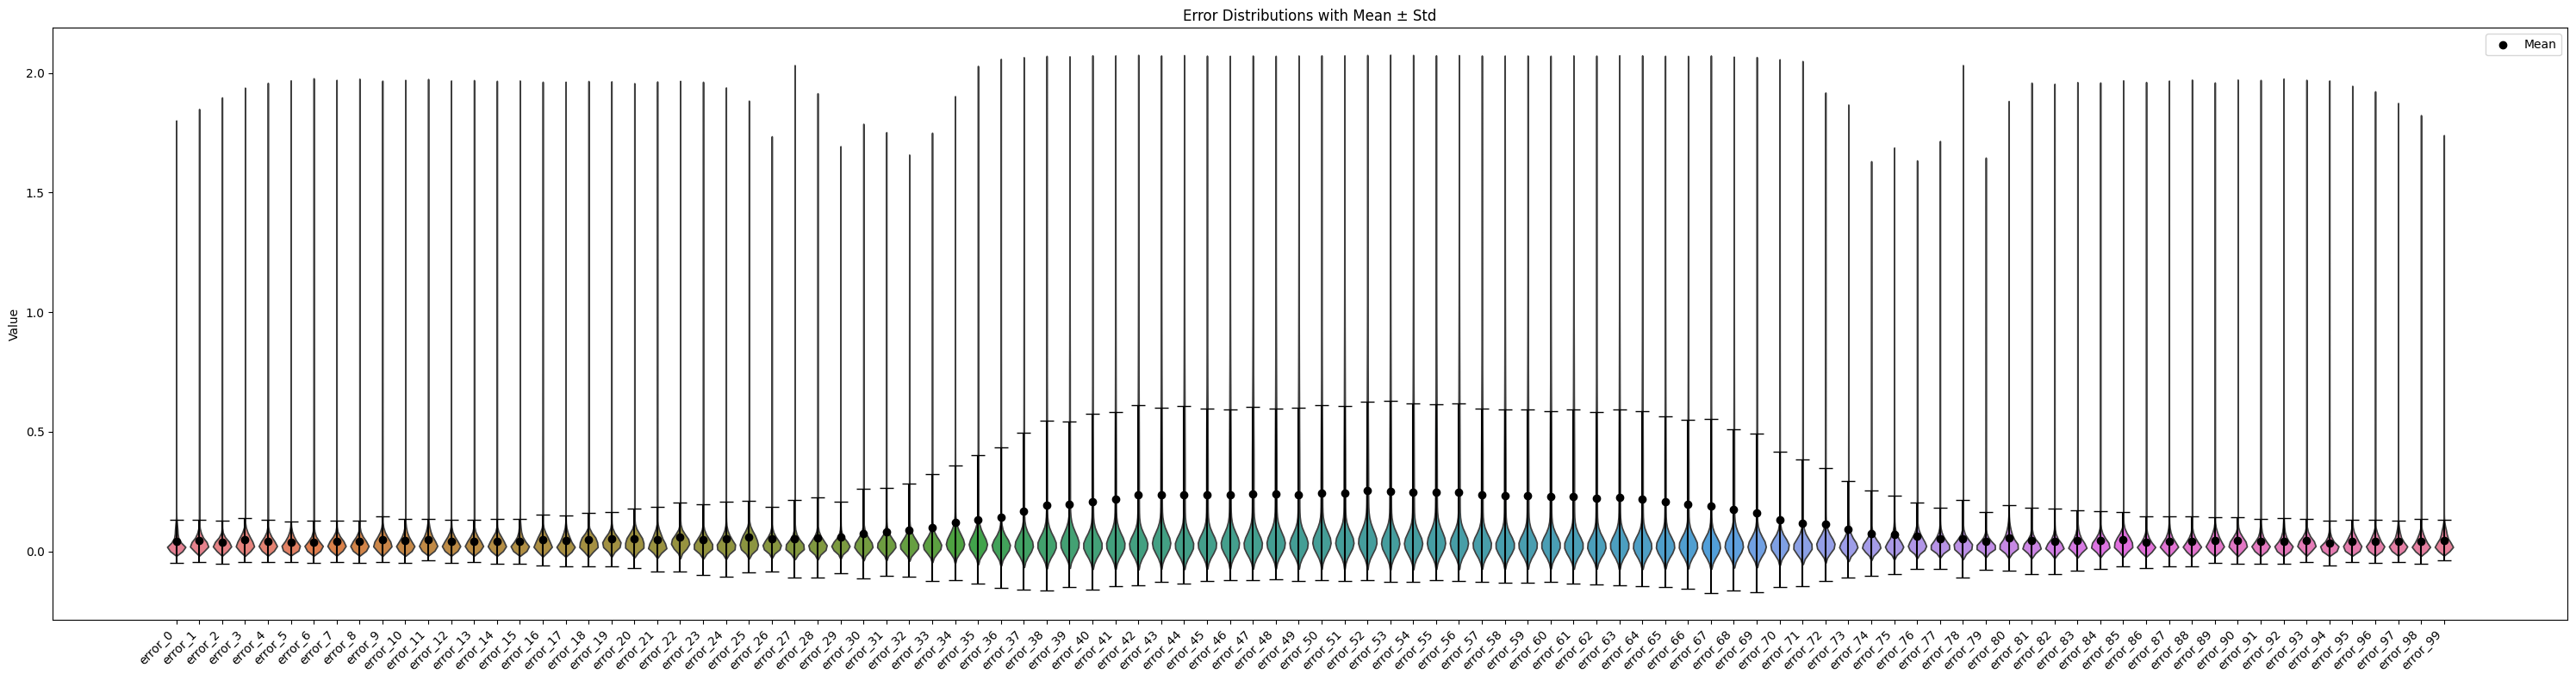

error_0     0.042422
error_1     0.043967
error_2     0.040049
error_3     0.048106
error_4     0.042528
              ...   
error_95    0.042406
error_96    0.042191
error_97    0.042485
error_98    0.042233
error_99    0.047169
Length: 100, dtype: float64 
 error_0     0.089972
error_1     0.088152
error_2     0.090121
error_3     0.092514
error_4     0.087820
              ...   
error_95    0.088525
error_96    0.090502
error_97    0.087407
error_98    0.092551
error_99    0.085218
Length: 100, dtype: float64 
               mean       std    median      skew   kurtosis  is_zero_test  \
error_0   0.042422  0.089972  0.022068  7.844746  75.223960         False   
error_1   0.043967  0.088152  0.029952  8.365959  82.307895         False   
error_2   0.040049  0.090121  0.026652  8.445861  82.190661         False   
error_3   0.048106  0.092514  0.033015  8.083773  77.718204         False   
error_4   0.042528  0.087820  0.028537  8.463425  85.066610         False   
...            .

In [7]:
means, std, summary = analyze_error_distribution('./data/results/bins_pglobal_error_dist.csv')
print(means,'\n', std, '\n', summary)

## KS TEST

In [8]:
# data simulation 
# example
X0_range = (0.8,0.8)
mu_range = (0.0, 0.0)
sigma_range = (0.4, 0.4)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1       # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

val.load_configuration('./models/bins/CGAN_bins_pglobal.json')
paths = val.get_paths()
pdfs = val.get_pdf(n_steps_ahead=10)
Xt = val.X_T
bins = val.bins



Bins loaded from models\bins\CGAN_bins_pglobal.json
Loaded 101 bins


In [9]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_pglobal')
conditional_gan.load_models()

CGAN config loaded from ./models\CGAN_bins_pglobal_config.json
Generator loaded from ./models\CGAN_bins_pglobal_generator.pth
Architecture: MyGenerator
Parameters: {'latent_size': 252, 'condition_size': 253, 'output_dim': 100, 'hidden_dims': [128, 256, 128], 'is_prob': True, 'use_batch_norm': True, 'activation': 'leaky_relu', 'dropout': 0.0}
Discriminator loaded from ./models\CGAN_bins_pglobal_discriminator.pth
Architecture: MyDiscriminator
Parameters: {'input_size': 100, 'condition_size': 253, 'output_dim': 1, 'hidden_dims': [256, 128], 'use_batch_norm': False, 'activation': 'leaky_relu', 'dropout': 0.0}


In [10]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='log')
preds, _ = conditional_gan.generate(mydata)

generated = np.exp(preds)
p_values = []
for i, row in enumerate(pdfs):
    _, p_value = ks_test_gan_cdf(generated[i], row)
    p_values.append(p_value)

test_df = pd.DataFrame({'p_values':p_values})
test_df


,p_values
0,5.867950e-10


In [11]:
test_h0 = test_df[test_df['p_values']>0.05]
print(len(test_h0)/len(test_df))
test_h0

0.0


,p_values


In [12]:
Xt

array([0.61457348])

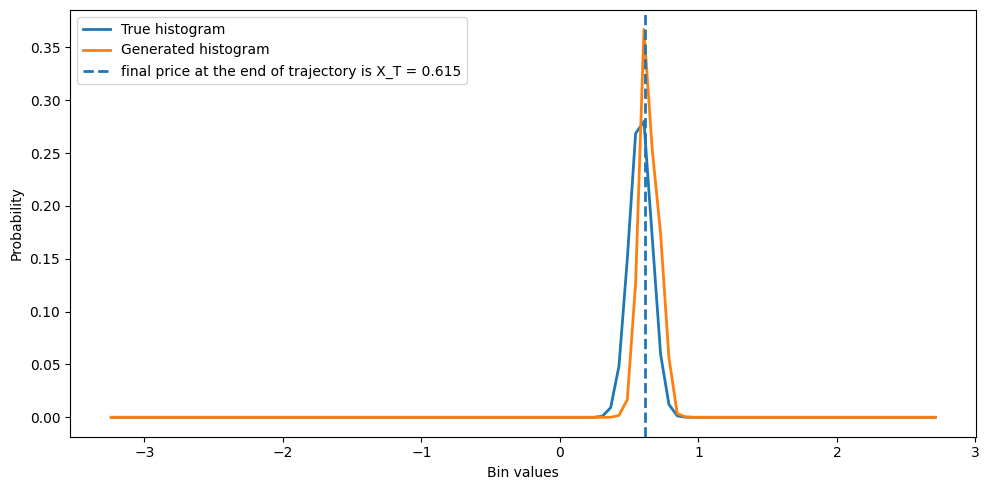

In [13]:
generated_sample = generated[-1]
true_sample = pdfs[-1]
plot_bin_dist(true_sample, generated_sample, bins, Xt[-1])



il problema qui è che il modello impara che tra x_min e x_max la densità è racchiusa in pochi bin. cosa che accade quando abbiamo 100 mila possibiliti pdf. nel singolo caso no, la distribuzione a seconda dei parametri è spalmata di piu tra i bin. manca l'informazione dei bin e del bin location (la distribuzione è centrata su Xt).

possibile soluzione salvare min_x e max_x del training o generate on vettore (2, bins) dove il primo è la pdf il secondo i bins value

X è in log scale ma C no. problema? No


possibile soluzione: generare una matrice 2XN dove N è il numero di bin ranges. la prima riga è la pdf, la seconda sono i bin edges (da eliminare il primo).


# BINS DISTRIBUTION EXPECTED VALUE

In [ ]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 100000        # Number of paths to simulate
SEED=42

# --- Run the Simulation ---
sim = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = sim.get_paths()
pdfs= sim.get_pdf(n_steps_ahead=10, n_bins=100, use_cdf=False)
pdfs

In [ ]:
mydata, _, _ = prepare_data(pdfs, paths, preprocess='standardization')


conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_ev')
conditional_gan.set_generator(condition_size=paths.shape[1], output_dim=pdfs.shape[1])
conditional_gan.set_discriminator(input_size=pdfs.shape[1], condition_size=paths.shape[1])
conditional_gan.train(mydata, save_history=True)
conditional_gan.save_models()
stats = conditional_gan.evaluate_error_distribution(mydata, 'bins_error_dist_ev.csv')


In [ ]:
plot_learning_curve('generated_vs_true.csv')

In [ ]:
means, std, summary = analyze_error_distribution('./data/results/bins_error_dist_ev.csv')
print(means,'\n', std, '\n', summary)

In [2]:
# data simulation 
# example
X0_range = (0.0,1.0)
mu_range = (0.0, 0.0)
sigma_range = (0.001, 1.0)
T = 1.0        # Time horizon (1 year)
N = 252        # Number of time steps
J = 1000        # Number of paths to simulate
SEED=2

#generate
val = DataSimulator(X0_range=X0_range, mu_range=mu_range, sigma_range=sigma_range, 
                            T=T, N=N, n_simulations=J, seed=SEED)

paths = val.get_paths()
pdfs= val.get_pdf(n_steps_ahead=10, n_bins=100, use_cdf=False)


In [ ]:
conditional_gan = MyCGAN(max_epoch=100, name='CGAN_bins_ev')
conditional_gan.load_models()

In [15]:

mydata, mean, std = prepare_data(pdfs, paths, preprocess='standardization')
preds, _ = conditional_gan.generate(mydata)

generated = preds*std.numpy() + mean.numpy()
true = mydata.tensors[0].numpy()*std.numpy() + mean.numpy()


In [ ]:

plot_bin_dist(true[0], generated[0], )

